# Grad-CAM — Explicabilite du modele EfficientNetB0

## Chargement du modele entraine et du split

In [3]:
import pandas as pd
import tensorflow as tf

model_eff = tf.keras.models.load_model('C:/Users/DELL/PneumoScan/ai-service/models/efficientnetb0_pneumonia.keras')

df_split = pd.read_csv('C:/Users/DELL/PneumoScan/data/split.csv')
test_paths = df_split[df_split['split'] == 'test']['path'].values
test_labels = df_split[df_split['split'] == 'test']['label'].values

print(model_eff.summary())
print(len(test_paths))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,541,864 (17.33 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,196 (1.25 MB)

None
880


### Acces a la derniere couche convolutionnelle et preparation d'une image

In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = model_eff.get_layer('efficientnetb0')
last_conv_layer_name = base_model.layers[-1].name
print('Derniere couche convolutionnelle :', last_conv_layer_name)

def get_img_array(path, size=(224, 224)):
    img = Image.open(path).convert('RGB').resize(size)
    array = np.array(img, dtype=np.float32)
    array = preprocess_input(array)
    return np.expand_dims(array, axis=0), img


Derniere couche convolutionnelle : top_activation


### Calcul du Grad-CAM

In [5]:
%%time
def make_gradcam_heatmap(img_array, model_eff, base_model, last_conv_layer_name):
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        base_model.input, [last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(img_array)
        x = base_output
        for layer in model_eff.layers[1:]:
            x = layer(x)
        preds = x
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds.numpy()[0][0]


CPU times: total: 0 ns
Wall time: 10 μs


### Superposition de la heatmap sur l'image originale et affichage

Label reel : PNEUMONIA - Score predit PNEUMONIA : 0.99997866


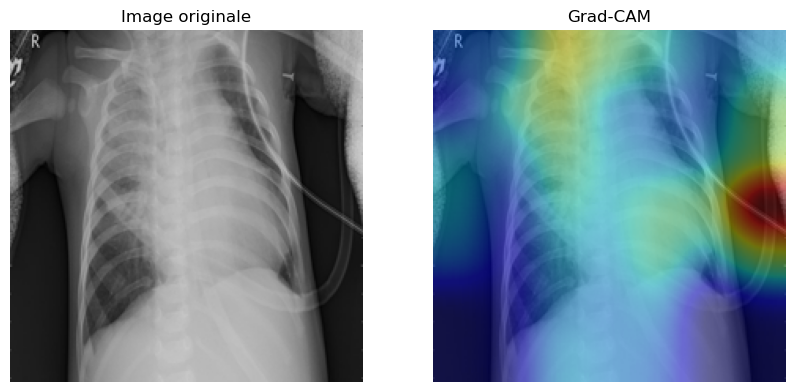

CPU times: total: 2.83 s
Wall time: 2.32 s


In [18]:
%%time 
def overlay_heatmap(heatmap, original_img, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    heatmap_img = Image.fromarray(heatmap).resize(original_img.size)
    heatmap_colored = plt.cm.jet(np.array(heatmap_img) / 255.0)[:, :, :3]
    heatmap_colored = np.uint8(255 * heatmap_colored)

    original_array = np.array(original_img)
    overlay = np.uint8(original_array * (1 - alpha) + heatmap_colored * alpha)
    return overlay

idx = 507
img_array, original_img = get_img_array(test_paths[idx])
heatmap, pred_score = make_gradcam_heatmap(img_array, model_eff, base_model, last_conv_layer_name)
overlay = overlay_heatmap(heatmap, original_img)

print('Label reel :', test_labels[idx], '- Score predit PNEUMONIA :', pred_score)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title('Image originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title('Grad-CAM')
plt.axis('off')
plt.show()


## Test sur une image externe (hors dataset)

Score predit PNEUMONIA : 0.03876334


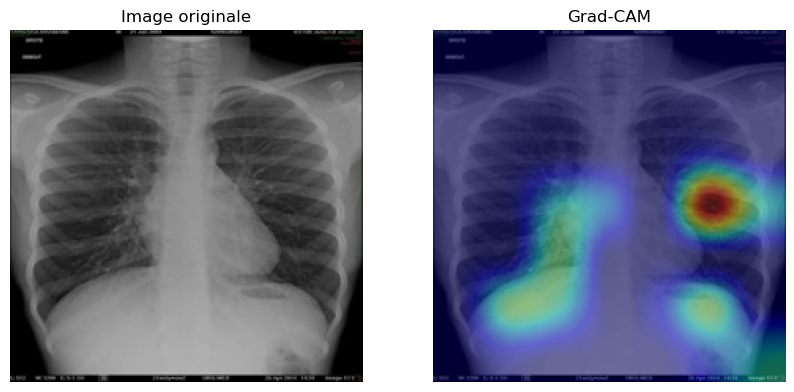

In [23]:
img_array, original_img = get_img_array(r"C:\Users\DELL\Desktop\pneumonia.jpg")
heatmap, pred_score = make_gradcam_heatmap(img_array, model_eff, base_model, last_conv_layer_name)
overlay = overlay_heatmap(heatmap, original_img)

print("Score predit PNEUMONIA :", pred_score)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")
plt.show()